In [ ]:
#!pip install transformers datasets accelerate scikit-learn

In [ ]:
import json
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset
import matplotlib.pyplot as plt

# Riproducibilità
torch.manual_seed(42)
np.random.seed(42)

/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0).
W0517 20:19:55.811000 19795 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Device: cpu


Data loading and split creation

In [3]:
path_json = "/Users/deniseatzori/Library/Mobile Documents/com~apple~CloudDocs/ENC-PSL/Cours/Python avancé/Data/enthymemes_2/merged_annotations_v2.json"

with open(path_json, "r", encoding="utf-8") as f:
    data = json.load(f)

tweets, labels = [], []
for entry in data:
    tweets.append(entry["tweet_text"])
    labels.append(0 if entry["majority_label"] == "none" else 1)
    # 0 = none, 1 = implicit

tweets  = np.array(tweets)
labels  = np.array(labels)

# Split identico ai notebook precedenti per confronto diretto
tweets_train, tweets_temp, y_train, y_temp = train_test_split(
    tweets, labels, test_size=0.3, random_state=42, stratify=labels
)
tweets_test, tweets_val, y_test, y_val = train_test_split(
    tweets_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train:      {len(tweets_train)}  (none={np.sum(y_train==0)}, implicit={np.sum(y_train==1)})")
print(f"Validation: {len(tweets_val)}  (none={np.sum(y_val==0)}, implicit={np.sum(y_val==1)})")
print(f"Test:       {len(tweets_test)}  (none={np.sum(y_test==0)}, implicit={np.sum(y_test==1)})")

Train:      933  (none=617, implicit=316)
Validation: 200  (none=133, implicit=67)
Test:       200  (none=132, implicit=68)


Model and tokenization

In [4]:
# Opzione A — RoBERTa pre-addestrato su Twitter (consigliato)
model_name = "cardiffnlp/twitter-roberta-base-2022-154m"

# Opzione B — RoBERTa base generale, più semplice da scaricare
# model_name = "roberta-base"

# Opzione C — BERT base, più leggero
# model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
print(f"Tokenizer caricato: {model_name}")

Tokenizer caricato: cardiffnlp/twitter-roberta-base-2022-154m


Tokenization and dataset creation

In [5]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128  # i tweet raramente superano 128 token
    )

def crea_dataset(testi, etichette):
    ds = Dataset.from_dict({"text": testi.tolist(), "label": etichette.tolist()})
    return ds.map(tokenize, batched=True)

ds_train = crea_dataset(tweets_train, y_train)
ds_val   = crea_dataset(tweets_val,   y_val)
ds_test  = crea_dataset(tweets_test,  y_test)

print(f"Dataset creati. Colonne: {ds_train.column_names}")

Map: 100%|██████████| 200/200 [00:00<00:00, 29652.20 examples/s]

Dataset creati. Colonne: ['text', 'label', 'input_ids', 'attention_mask']


Evaluation metrics

In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    f1_macro    = f1_score(labels, predictions, average='macro',    zero_division=0)
    f1_implicit = f1_score(labels, predictions, average='binary',   zero_division=0, pos_label=1)
    f1_none     = f1_score(labels, predictions, average='binary',   zero_division=0, pos_label=0)
    
    return {
        'f1_macro':    round(f1_macro, 4),
        'f1_implicit': round(f1_implicit, 4),
        'f1_none':     round(f1_none, 4),
    }

Managing imbalance with a custom trainer

In [11]:
# Rileva correttamente il device, includendo MPS per Apple Silicon
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Device: {device}")

n_none     = np.sum(y_train == 0)
n_implicit = np.sum(y_train == 1)
n_total    = len(y_train)

weight_none     = n_total / (2 * n_none)
weight_implicit = n_total / (2 * n_implicit)

print(f"Class weights: none={weight_none:.3f}, implicit={weight_implicit:.3f}")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Sposta i pesi sul device del modello a runtime, non a priori
        weights = torch.tensor(
            [weight_none, weight_implicit],
            dtype=torch.float,
            device=logits.device  # <-- usa il device effettivo del modello
        )
        loss = torch.nn.functional.cross_entropy(logits, labels, weight=weights)
        return (loss, outputs) if return_outputs else loss

Device: mps
Class weights: none=0.756, implicit=1.476


In [16]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=20,
    seed=42,
    fp16=False,   # fp16 non supportato su MPS
    bf16=False,   # bf16 non supportato su MPS
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: "none", 1: "implicit"},
    label2id={"none": 0, "implicit": 1},
    ignore_mismatched_sizes=True
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    # si ferma se l'F1 macro sul validation non migliora per 2 epoch consecutive
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3180.95it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Implicit,F1 None
1,0.687210,0.663695,0.585000,0.520700,0.649400
2,0.652838,0.812513,0.473900,0.550200,0.397700
3,0.508134,0.657464,0.632200,0.551300,0.713100
4,0.396097,0.738118,0.644000,0.597700,0.690300
5,0.292251,0.834723,0.638300,0.560500,0.716000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.06it/s]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.02s/it]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.42it/s]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████

TrainOutput(global_step=295, training_loss=0.5126339443659378, metrics={'train_runtime': 269.2616, 'train_samples_per_second': 17.325, 'train_steps_per_second': 1.096, 'total_flos': 306853268313600.0, 'train_loss': 0.5126339443659378, 'epoch': 5.0})

In [19]:
# Valutazione con il Trainer
test_results = trainer.evaluate(ds_test)
print(f"Test F1 macro:    {test_results['eval_f1_macro']:.4f}")
print(f"Test F1 implicit: {test_results['eval_f1_implicit']:.4f}")
print(f"Test F1 none:     {test_results['eval_f1_none']:.4f}")

# Report completo
predictions = trainer.predict(ds_test)
y_pred = np.argmax(predictions.predictions, axis=-1)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=["none", "implicit"], zero_division=0))

/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Test F1 macro:    0.6410
Test F1 implicit: 0.6034
Test F1 none:     0.6787


/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



=== Classification Report ===
              precision    recall  f1-score   support

        none       0.84      0.57      0.68       132
    implicit       0.49      0.79      0.60        68

    accuracy                           0.65       200
   macro avg       0.66      0.68      0.64       200
weighted avg       0.72      0.65      0.65       200



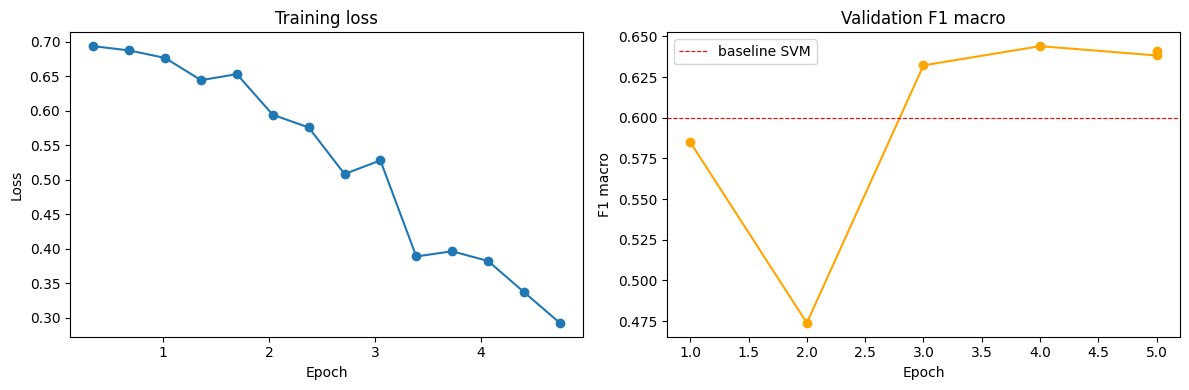

In [20]:
log_history = trainer.state.log_history

train_loss = [(e['epoch'], e['loss'])      for e in log_history if 'loss' in e and 'eval_loss' not in e]
eval_f1    = [(e['epoch'], e['eval_f1_macro']) for e in log_history if 'eval_f1_macro' in e]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(*zip(*train_loss), marker='o')
ax1.set_title("Training loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2.plot(*zip(*eval_f1), marker='o', color='orange')
ax2.set_title("Validation F1 macro")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1 macro")
ax2.axhline(0.60, color='red', linestyle='--', linewidth=0.8, label='baseline SVM')
ax2.legend()

plt.tight_layout()
plt.show()

Search for optimization

In [24]:
# 1: Learning rate optimization

for lr in [1e-5, 3e-5, 5e-5]:
    print(f"\n--- Learning rate: {lr} ---")
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        id2label={0: "none", 1: "implicit"},
        label2id={"none": 0, "implicit": 1},
        ignore_mismatched_sizes=True
    )
    
    args = TrainingArguments(
        output_dir=f"./results_lr{lr}",
        num_train_epochs=5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=lr,
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_steps=20,
        seed=42,
        fp16=False,
        bf16=False,
    )
    
    t = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=ds_train,
        eval_dataset=ds_val,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )
    t.train()
    
    preds = np.argmax(t.predict(ds_test).predictions, axis=-1)
    print(classification_report(y_test, preds, target_names=["none", "implicit"], zero_division=0))


--- Learning rate: 1e-05 ---


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2977.69it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Implicit,F1 None
1,0.692834,0.681066,0.519600,0.534000,0.505200
2,0.665418,0.655021,0.582700,0.551400,0.614000
3,0.610382,0.637900,0.624200,0.535900,0.712600
4,0.578737,0.645892,0.614500,0.550900,0.678100
5,0.524038,0.644425,0.613700,0.522900,0.704500


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.21it/s]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.09it/s]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.22s/it]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████

              precision    recall  f1-score   support

        none       0.79      0.70      0.74       132
    implicit       0.52      0.63      0.57        68

    accuracy                           0.68       200
   macro avg       0.65      0.66      0.65       200
weighted avg       0.70      0.68      0.68       200


--- Learning rate: 3e-05 ---


...

              precision    recall  f1-score   support

        none       0.82      0.60      0.69       132
    implicit       0.49      0.75      0.59        68

    accuracy                           0.65       200
   macro avg       0.66      0.67      0.64       200
weighted avg       0.71      0.65      0.66       200


--- Learning rate: 5e-05 ---


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1829.21it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Implicit,F1 None
1,0.688263,0.666132,0.581400,0.388900,0.774000
2,0.606250,0.633338,0.584200,0.602900,0.565400
3,0.448047,0.692445,0.601000,0.541200,0.660900
4,0.219825,0.896594,0.652200,0.600000,0.704300
5,0.116606,1.489408,0.630600,0.518000,0.743300


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.07s/it]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.05s/it]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.13s/it]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████

              precision    recall  f1-score   support

        none       0.83      0.59      0.69       132
    implicit       0.49      0.76      0.60        68

    accuracy                           0.65       200
   macro avg       0.66      0.68      0.64       200
weighted avg       0.71      0.65      0.66       200



/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Soglia ottimale: 0.3994
              precision    recall  f1-score   support

        none       0.83      0.48      0.61       132
    implicit       0.44      0.81      0.57        68

    accuracy                           0.59       200
   macro avg       0.64      0.64      0.59       200
weighted avg       0.70      0.59      0.59       200



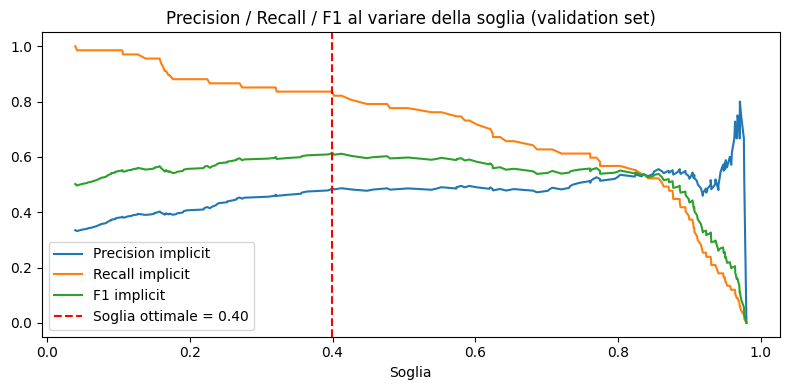

In [22]:
# 2: Bilancing precision and recall with treshold
from sklearn.metrics import precision_recall_curve

# Estrai le probabilità (serve il modello calibrato o i logit softmax)
raw = trainer.predict(ds_test)
probs = torch.softmax(torch.tensor(raw.predictions), dim=-1).numpy()
scores_implicit = probs[:, 1]  # probabilità classe implicit

# Curva precision-recall sul validation set
raw_val = trainer.predict(ds_val)
probs_val = torch.softmax(torch.tensor(raw_val.predictions), dim=-1).numpy()
scores_val = probs_val[:, 1]

precisions, recalls, soglie = precision_recall_curve(y_val, scores_val, pos_label=1)
f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_soglia = soglie[np.argmax(f1s)]

print(f"Soglia ottimale: {best_soglia:.4f}")

# Applica al test
y_pred_soglia = (scores_implicit >= best_soglia).astype(int)
print(classification_report(y_test, y_pred_soglia, target_names=["none", "implicit"], zero_division=0))

# Visualizzazione
plt.figure(figsize=(8, 4))
plt.plot(soglie, precisions[:-1], label='Precision implicit')
plt.plot(soglie, recalls[:-1],    label='Recall implicit')
plt.plot(soglie, f1s[:-1],        label='F1 implicit')
plt.axvline(best_soglia, color='red', linestyle='--', label=f'Soglia ottimale = {best_soglia:.2f}')
plt.xlabel('Soglia')
plt.legend()
plt.title('Precision / Recall / F1 al variare della soglia (validation set)')
plt.tight_layout()
plt.show()

In [25]:
# 3: fixing the class weights
# Invece dei pesi calcolati automaticamente, prova valori manuali
# Il rapporto attuale è circa 882/451 ≈ 2:1
# Prova a smorzarlo

for w_implicit in [1.5, 2.0, 2.5]:
    w_none = 1.0
    print(f"\n--- weights: none={w_none}, implicit={w_implicit} ---")
    
    class WeightedTrainerCustom(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            weights = torch.tensor(
                [w_none, w_implicit], dtype=torch.float, device=logits.device
            )
            loss = torch.nn.functional.cross_entropy(logits, labels, weight=weights)
            return (loss, outputs) if return_outputs else loss
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2, ignore_mismatched_sizes=True
    )
    t = WeightedTrainerCustom(
        model=model, args=training_args,
        train_dataset=ds_train, eval_dataset=ds_val,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )
    t.train()
    preds = np.argmax(t.predict(ds_test).predictions, axis=-1)
    print(classification_report(y_test, preds, target_names=["none", "implicit"], zero_division=0))


--- weights: none=1.0, implicit=1.5 ---


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3285.35it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Implicit,F1 None
1,0.677787,0.644400,0.618400,0.471500,0.765300
2,0.612473,0.722322,0.528800,0.583000,0.474600
3,0.464555,0.636311,0.653100,0.589000,0.717300
4,0.352224,0.773571,0.649500,0.605700,0.693300
5,0.275646,0.816361,0.654800,0.561600,0.748000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.22it/s]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.35it/s]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.19it/s]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████

              precision    recall  f1-score   support

        none       0.80      0.66      0.72       132
    implicit       0.51      0.68      0.58        68

    accuracy                           0.67       200
   macro avg       0.65      0.67      0.65       200
weighted avg       0.70      0.67      0.67       200


--- weights: none=1.0, implicit=2.0 ---


...

              precision    recall  f1-score   support

        none       0.80      0.68      0.73       132
    implicit       0.52      0.66      0.58        68

    accuracy                           0.68       200
   macro avg       0.66      0.67      0.66       200
weighted avg       0.70      0.68      0.68       200


--- weights: none=1.0, implicit=2.5 ---


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3176.35it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Implicit,F1 None
1,0.700753,0.663511,0.496800,0.537000,0.456500
2,0.659178,0.765097,0.435700,0.540100,0.331300
3,0.532255,0.636274,0.629300,0.566300,0.692300
4,0.456305,0.691880,0.616900,0.582400,0.651400
5,0.355365,0.703128,0.668000,0.604900,0.731100


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.37it/s]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.59it/s]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.05it/s]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████

              precision    recall  f1-score   support

        none       0.79      0.64      0.71       132
    implicit       0.49      0.68      0.57        68

    accuracy                           0.65       200
   macro avg       0.64      0.66      0.64       200
weighted avg       0.69      0.65      0.66       200



In [ ]:
#!pip install deep-translator

In [26]:
# 4: data augmentation and back-translation
# translate the implicit tweets into another language and then back-translate them into English to produce paraphrases:

from deep_translator import GoogleTranslator

def back_translate(testo, lingua_intermedia="fr"):
    try:
        tradotto  = GoogleTranslator(source='en', target=lingua_intermedia).translate(testo)
        ritradotto = GoogleTranslator(source=lingua_intermedia, target='en').translate(tradotto)
        return ritradotto
    except:
        return testo  # fallback al testo originale in caso di errore

# Applica solo agli implicit del training set
implicit_mask = y_train == 1
tweets_implicit = tweets_train[implicit_mask]

print(f"Augmenting {len(tweets_implicit)} implicit examples...")
augmented = [back_translate(t) for t in tweets_implicit]

# Aggiungi al training set
tweets_train_aug = np.concatenate([tweets_train, np.array(augmented)])
y_train_aug      = np.concatenate([y_train, np.ones(len(augmented), dtype=int)])

print(f"Training set dopo augmentation: {len(tweets_train_aug)} esempi")
print(f"  none={np.sum(y_train_aug==0)}, implicit={np.sum(y_train_aug==1)}")

# Ricrea il dataset e riaddestra
ds_train_aug = crea_dataset(tweets_train_aug, y_train_aug)

Augmenting 316 implicit examples...
Training set dopo augmentation: 1249 esempi
  none=617, implicit=632


Map: 100%|██████████| 1249/1249 [00:00<00:00, 17873.25 examples/s]


In [27]:
# retraining with syntetics data
model_aug = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: "none", 1: "implicit"},
    label2id={"none": 0, "implicit": 1},
    ignore_mismatched_sizes=True
)

# Ricalcola i class weights sul training set aumentato
n_none_aug     = np.sum(y_train_aug == 0)
n_implicit_aug = np.sum(y_train_aug == 1)
n_total_aug    = len(y_train_aug)

print(f"Training aumentato: none={n_none_aug}, implicit={n_implicit_aug}")

class WeightedTrainerAug(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weights = torch.tensor(
            [n_total_aug / (2 * n_none_aug),
             n_total_aug / (2 * n_implicit_aug)],
            dtype=torch.float,
            device=logits.device
        )
        loss = torch.nn.functional.cross_entropy(logits, labels, weight=weights)
        return (loss, outputs) if return_outputs else loss

training_args_aug = TrainingArguments(
    output_dir="./results_aug",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,       # sostituisci con il lr migliore trovato nella Leva 1
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=20,
    seed=42,
    fp16=False,
    bf16=False,
)

trainer_aug = WeightedTrainerAug(
    model=model_aug,
    args=training_args_aug,
    train_dataset=ds_train_aug,
    eval_dataset=ds_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer_aug.train()

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3925.40it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

Training aumentato: none=617, implicit=632


/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Implicit,F1 None
1,0.685998,0.659550,0.611700,0.506800,0.716500
2,0.518207,0.834035,0.591300,0.552500,0.630100
3,0.274462,1.024570,0.645800,0.575000,0.716700
4,0.132152,1.761095,0.601400,0.563500,0.639300
5,0.063065,1.755626,0.645800,0.575000,0.716700


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.69s/it]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.51it/s]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.05it/s]
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████

TrainOutput(global_step=395, training_loss=0.33379005012632923, metrics={'train_runtime': 347.1175, 'train_samples_per_second': 17.991, 'train_steps_per_second': 1.138, 'total_flos': 410782135180800.0, 'train_loss': 0.33379005012632923, 'epoch': 5.0})

In [28]:
# validation with optimaized threshold
# Soglia ottimale sul validation set
raw_val_aug = trainer_aug.predict(ds_val)
probs_val_aug = torch.softmax(torch.tensor(raw_val_aug.predictions), dim=-1).numpy()
scores_val_aug = probs_val_aug[:, 1]

precisions, recalls, soglie = precision_recall_curve(y_val, scores_val_aug, pos_label=1)
f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_soglia_aug = soglie[np.argmax(f1s)]

print(f"Soglia ottimale (validation): {best_soglia_aug:.4f}")

# Applica al test
raw_test_aug = trainer_aug.predict(ds_test)
probs_test_aug = torch.softmax(torch.tensor(raw_test_aug.predictions), dim=-1).numpy()
scores_test_aug = probs_test_aug[:, 1]

y_pred_aug = (scores_test_aug >= best_soglia_aug).astype(int)

print("\n=== Test set — modello aumentato con soglia ottimizzata ===")
print(classification_report(y_test, y_pred_aug, target_names=["none", "implicit"], zero_division=0))

/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Soglia ottimale (validation): 0.2827


/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



=== Test set — modello aumentato con soglia ottimizzata ===
              precision    recall  f1-score   support

        none       0.77      0.60      0.67       132
    implicit       0.45      0.65      0.53        68

    accuracy                           0.61       200
   macro avg       0.61      0.62      0.60       200
weighted avg       0.66      0.61      0.63       200



In [32]:
import pandas as pd

/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


                              modello  F1 macro  F1 implicit  precision implicit  recall implicit  F1 none
       Transformer (base, soglia=0.5)    0.6410       0.6034              0.4865           0.7941   0.6787
Transformer (aug, soglia ottimizzata)    0.6028       0.5333              0.4536           0.6471   0.6723


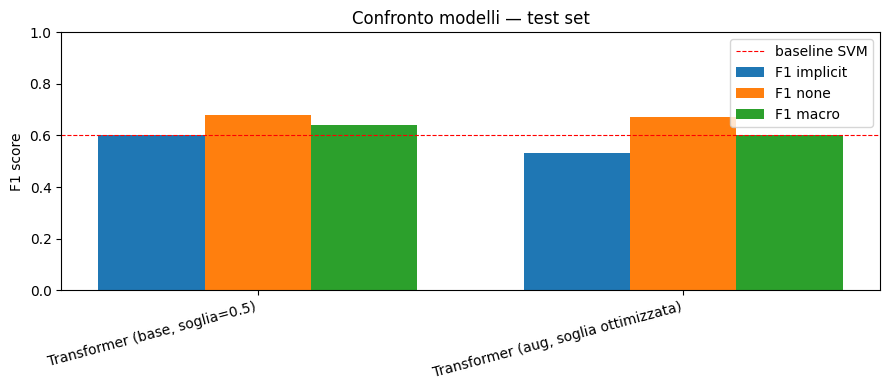

In [33]:
# confrontation
# Raccogli le predizioni del modello base (senza augmentation) con soglia default
raw_base = trainer.predict(ds_test)
probs_base = torch.softmax(torch.tensor(raw_base.predictions), dim=-1).numpy()
y_pred_base = np.argmax(probs_base, axis=-1)

# Confronto
modelli = {
    "Transformer (base, soglia=0.5)":       y_pred_base,
    "Transformer (aug, soglia ottimizzata)": y_pred_aug,
}

rows = []
for nome, preds in modelli.items():
    report = classification_report(
        y_test, preds,
        target_names=["none", "implicit"],  # forza i nomi delle classi
        output_dict=True,
        zero_division=0
    )
    rows.append({
        "modello":            nome,
        "F1 macro":           round(report["macro avg"]["f1-score"], 4),
        "F1 implicit":        round(report["implicit"]["f1-score"], 4),
        "precision implicit": round(report["implicit"]["precision"], 4),
        "recall implicit":    round(report["implicit"]["recall"], 4),
        "F1 none":            round(report["none"]["f1-score"], 4),
    })

df_confronto = pd.DataFrame(rows)
print(df_confronto.to_string(index=False))

# Visualizzazione
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(df_confronto))
width = 0.25

ax.bar(x - width, df_confronto["F1 implicit"], width, label="F1 implicit")
ax.bar(x,         df_confronto["F1 none"],     width, label="F1 none")
ax.bar(x + width, df_confronto["F1 macro"],    width, label="F1 macro")

ax.set_xticks(x)
ax.set_xticklabels(df_confronto["modello"], rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("F1 score")
ax.set_title("Confronto modelli — test set")
ax.axhline(0.60, color="red", linestyle="--", linewidth=0.8, label="baseline SVM")
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
# Salva modello e tokenizer per riuso futuro senza riaddestrare
trainer_aug.save_model("./modello_finale")
tokenizer.save_pretrained("./modello_finale")
print("Modello salvato in ./modello_finale")

# Per ricaricare in futuro:
# model_ricaricato = AutoModelForSequenceClassification.from_pretrained("./modello_finale")
# tokenizer_ricaricato = AutoTokenizer.from_pretrained("./modello_finale")

Writing model shards: 100%|██████████| 1/1 [00:38<00:00, 38.63s/it]


Modello salvato in ./modello_finale
